**Exercise 2 — Background Subtraction**

- Load the sequence of frames from the `Barcelona-sequence` folder.
- Compute the average background image.
- Subtract it from each frame to obtain binary foreground masks (threshold manually).
- Extract the foreground for each frame.
- Plot the foreground for every 20th frame in the sequence as shown below:

<img src="E2Output.png"/>

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

In [19]:
def load_images_from_folder(folder):
    images = []
    for filename in sorted(os.listdir(folder)):
        img = io.imread(os.path.join(folder, filename))
        if img is not None:
            images.append(img)
    return images

In [20]:
def compute_background(frames):
    # Convertir la lista de frames en un array de numpy 4D (número de frames, altura, anchura, canales)
    frame_stack = np.array(frames)
    # Calcular la mediana a lo largo del eje temporal (axis=0)
    background = np.median(frame_stack, axis=0).astype(np.uint8)
    return background

In [32]:
# Paso 3: Restar el background de cada frame para obtener el primer plano (foreground)
def subtract_background(frame, background_image, threshold=90):
    # Calcular la diferencia absoluta entre el frame y el background
    # NOTA IMPORTANTE: Se convierte a int32 para evitar que los números negativos den la vuelta (overflow) en uint8
    foreground = np.abs(frame.astype(np.int32) - background_image.astype(np.int32))
    
    # Aplicar un umbral para aislar los píxeles interesantes (primer plano)
    mask = np.max(foreground, axis=2) > threshold  # Umbral sobre la diferencia máxima en cualquiera de los canales
    
    # Crear una máscara para resaltar los objetos en primer plano
    foreground_image = np.zeros_like(frame)
    foreground_image[mask] = frame[mask]  # Extraer los píxeles del primer plano del frame
    return foreground_image

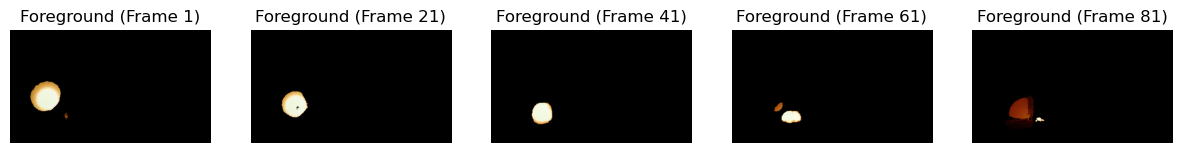

In [41]:

# Paso 1: Cargar los frames

folder = 'Barcelona-sequence'
frames = load_images_from_folder(folder)

# Paso 2: Calcular la imagen background usando un filtro de mediana sobre todos los frames
# El background se calcula como la mediana de los valores de píxel a lo largo del eje del tiempo (eje temporal)

foreground_images = []

background_image = compute_background(frames)
for i in range(0,len(frames)):
    
    # Calculamos la imagen foreground para cada frame
    foreground_image = subtract_background(frames[i], background_image)
    foreground_images.append(foreground_image)

# Ploteamos los resultados
fig, ax = plt.subplots(1, 5, figsize=(15, 5))


# Hacemos un plot del foreground para cada 20 frames en la secuencia
for i in range(0,5):
    
    # Ploteamos el frame
    ax[i].imshow(foreground_images[i*20])
    ax[i].set_title(f'Foreground (Frame {20*i +1})')
    ax[i].axis('off')


